In [60]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
import warnings

# Cấu hình hiển thị
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [61]:
data_dir = r"D:\DOWNLOAD\shopping-behavior-demo-Thanh\shopping-behavior-demo-Thanh\backend\shopping_behavior_updated.csv"
df = pd.read_csv(data_dir)

In [62]:
print(df.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Code Used  Previ

In [63]:
df.sample(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
601,602,32,Male,Backpack,Accessories,38,West Virginia,M,Maroon,Summer,4.7,Yes,Store Pickup,Yes,Yes,5,Cash,Fortnightly
1579,1580,35,Male,Jacket,Outerwear,80,Oklahoma,M,Violet,Summer,3.1,No,Free Shipping,Yes,Yes,6,Bank Transfer,Monthly
329,330,70,Male,Socks,Clothing,31,Nevada,S,White,Summer,2.9,Yes,2-Day Shipping,Yes,Yes,34,Bank Transfer,Monthly
3262,3263,42,Female,T-shirt,Clothing,35,Indiana,M,Violet,Spring,2.7,No,Standard,No,No,21,Cash,Every 3 Months
1159,1160,66,Male,Handbag,Accessories,55,New Hampshire,L,Blue,Fall,3.6,No,2-Day Shipping,Yes,Yes,46,Venmo,Every 3 Months
1960,1961,57,Male,Jeans,Clothing,72,Massachusetts,L,Red,Summer,3.3,No,2-Day Shipping,No,No,40,Credit Card,Annually
3478,3479,36,Female,Handbag,Accessories,57,Arizona,M,Magenta,Fall,4.6,No,Store Pickup,No,No,42,PayPal,Quarterly
3636,3637,50,Female,Sandals,Footwear,38,California,L,Lavender,Summer,4.2,No,2-Day Shipping,No,No,36,Cash,Weekly
1292,1293,26,Male,Belt,Accessories,61,Kentucky,M,Maroon,Summer,3.9,No,Free Shipping,Yes,Yes,42,Bank Transfer,Annually
3610,3611,18,Female,Jacket,Outerwear,86,Texas,XL,Green,Fall,4.8,No,2-Day Shipping,No,No,23,Bank Transfer,Fortnightly


In [64]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [65]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [66]:
# Thống kê số lượng giá trị duy nhất cho từng cột (Numerical & Categorical)
print("\n--- SỐ LƯỢNG GIÁ TRỊ DUY NHẤT (Unique Values) ---")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} giá trị")


--- SỐ LƯỢNG GIÁ TRỊ DUY NHẤT (Unique Values) ---
Customer ID: 3900 giá trị
Age: 53 giá trị
Gender: 2 giá trị
Item Purchased: 25 giá trị
Category: 4 giá trị
Purchase Amount (USD): 81 giá trị
Location: 50 giá trị
Size: 4 giá trị
Color: 25 giá trị
Season: 4 giá trị
Review Rating: 26 giá trị
Subscription Status: 2 giá trị
Shipping Type: 6 giá trị
Discount Applied: 2 giá trị
Promo Code Used: 2 giá trị
Previous Purchases: 50 giá trị
Payment Method: 6 giá trị
Frequency of Purchases: 7 giá trị


EDA các cột num

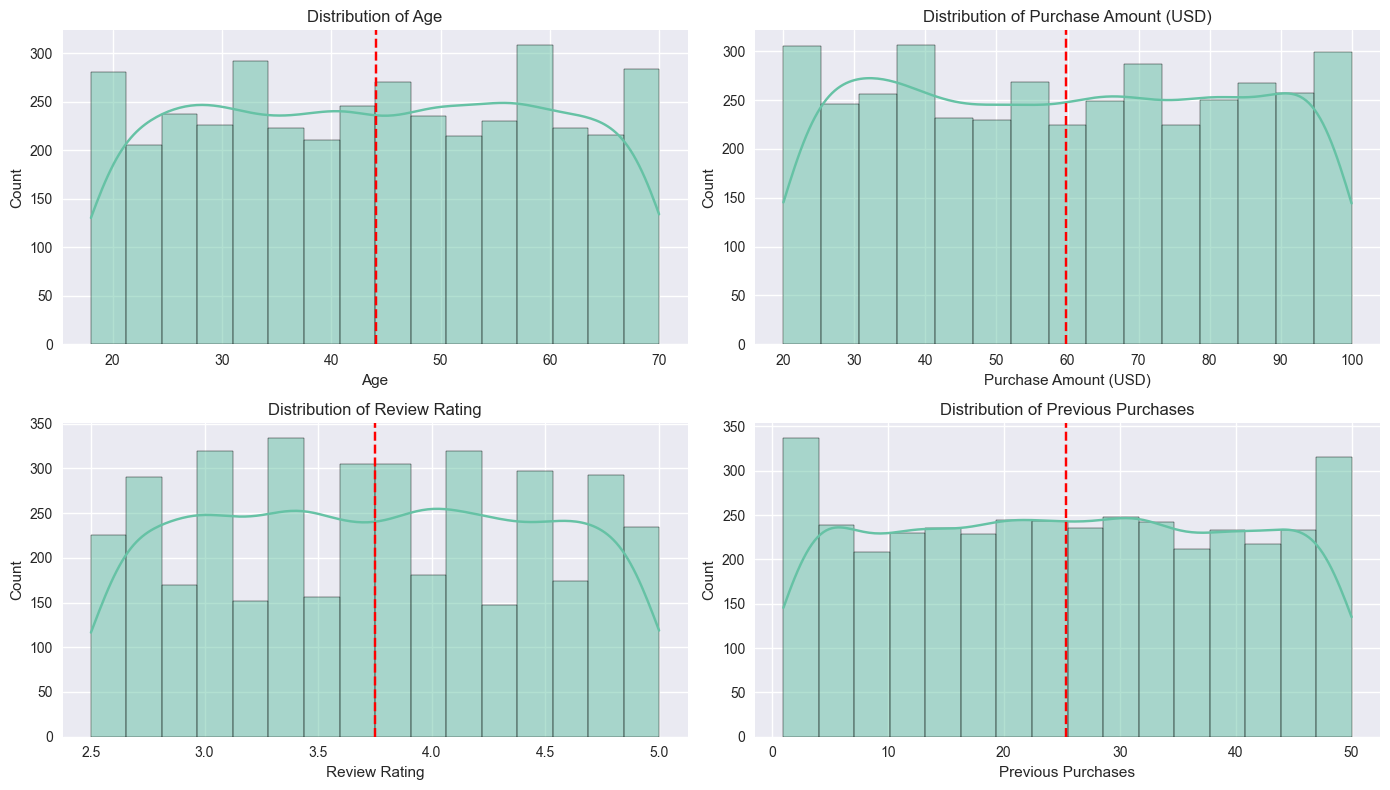

In [67]:
numeric_cols = ['Age','Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

plt.figure(figsize=(14,8))
for i,col in enumerate(numeric_cols):
    plt.subplot(2,2,i+1)
    sns.histplot(df[col], kde=True)
    plt.axvline(df[col].mean(), color='red', ls='--')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Kiểm tra Outlier

In [68]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Purchase Amount (USD): 0 outliers
Review Rating: 0 outliers
Previous Purchases: 0 outliers


Bảng Correlation cho cột số

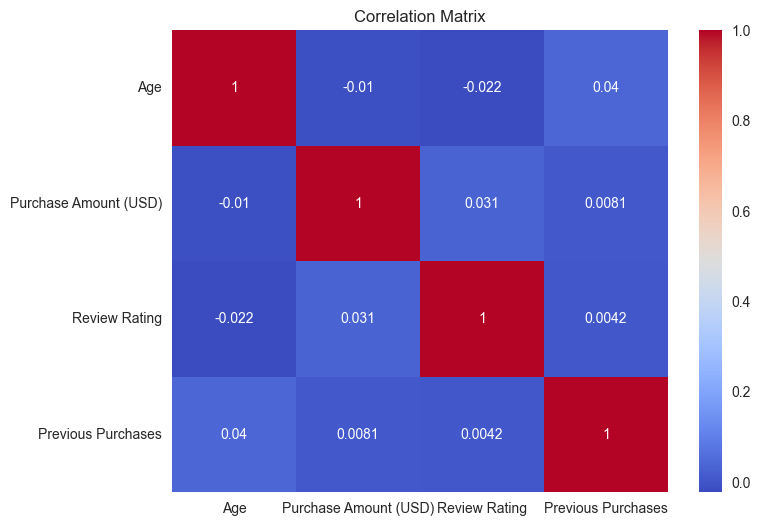

In [69]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [70]:
TARGET_COL = "Subscription Status"
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip().str.lower()

KEY_TRUE = "yes"
KEY_FALSE = "no"

Tỷ lệ các lớp trong Subscription Status
Subscription Status
no     73.0
yes    27.0
Name: proportion, dtype: float64


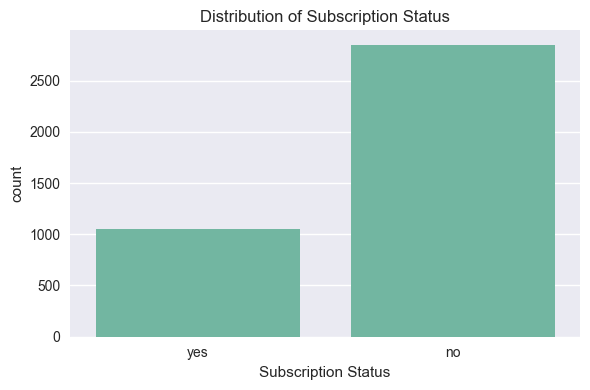

In [71]:
print("Tỷ lệ các lớp trong Subscription Status")
target_counts = df[TARGET_COL].value_counts(normalize=True) * 100
print(target_counts)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x=TARGET_COL)
plt.title("Distribution of Subscription Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Phân tích những đặc trưng số với cột Subscription Status

In [72]:
numeric_features = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases",
]

In [73]:
numeric_comparison = df.groupby(TARGET_COL)[numeric_features].mean()
print("Bảng so sánh Giá trị Trung bình:")
print(numeric_comparison)

Bảng so sánh Giá trị Trung bình:
                           Age  Purchase Amount (USD)  Review Rating  \
Subscription Status                                                    
no                   44.008430              59.865121       3.752722   
yes                  44.230769              59.491928       3.742450   

                     Previous Purchases  
Subscription Status                      
no                            25.080436  
yes                           26.084520  


In [74]:
diff = numeric_comparison.loc[KEY_TRUE] - numeric_comparison.loc[KEY_FALSE] 
print(f"\n* Độ chênh lệch ({KEY_TRUE} - {KEY_FALSE}), sắp xếp giảm dần:")
print(diff.sort_values(ascending=False))


* Độ chênh lệch (yes - no), sắp xếp giảm dần:
Previous Purchases       1.004085
Age                      0.222339
Review Rating           -0.010272
Purchase Amount (USD)   -0.373193
dtype: float64


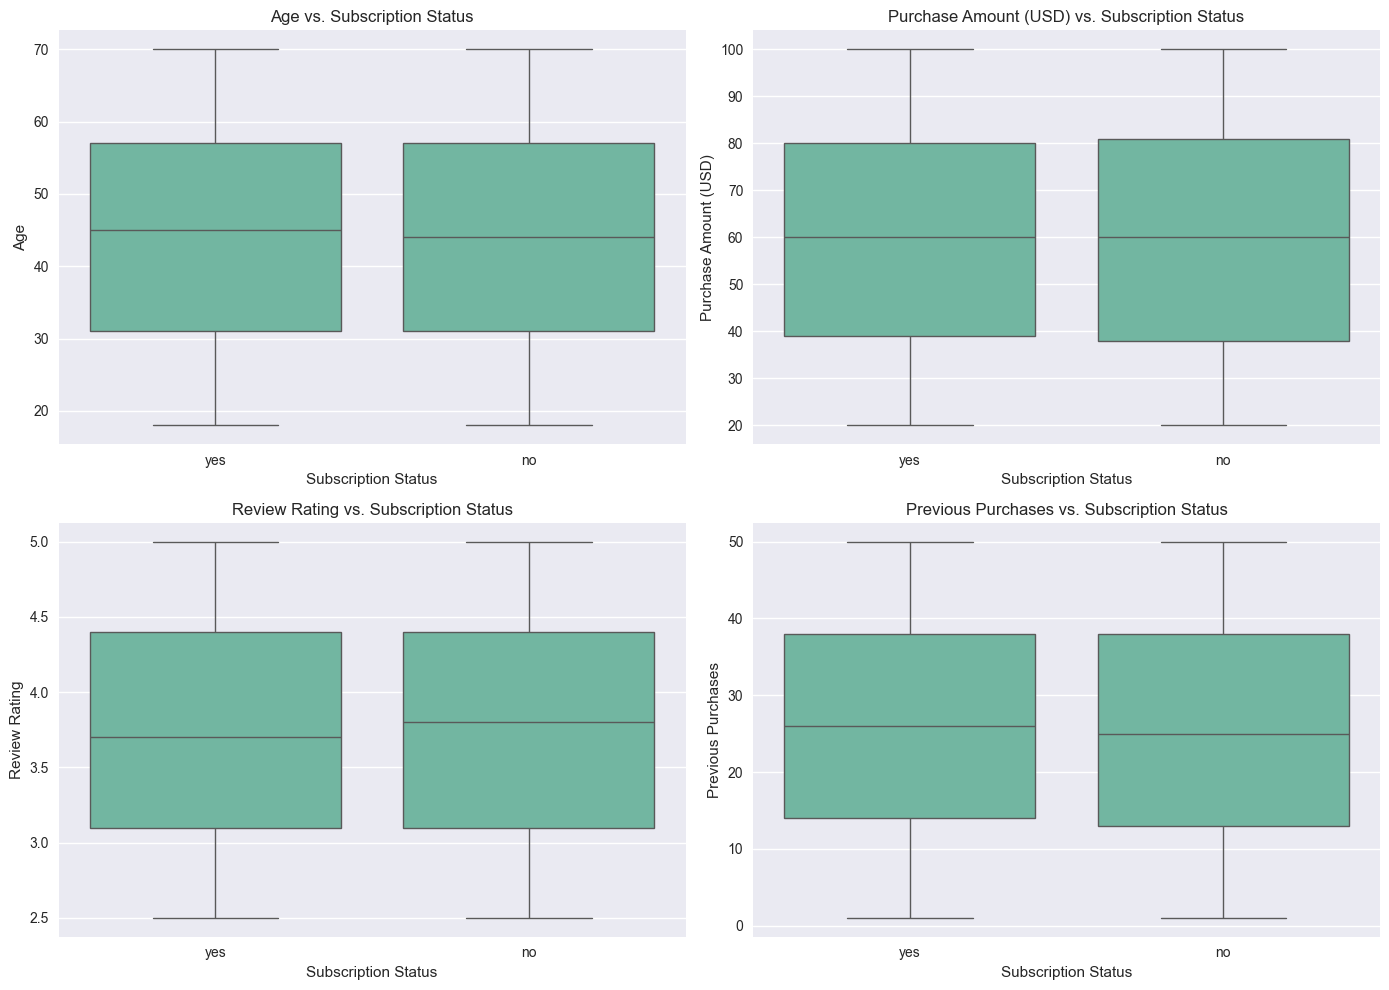

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x=TARGET_COL, y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs. {TARGET_COL}')

plt.tight_layout()
plt.show()

EDA các cột cat

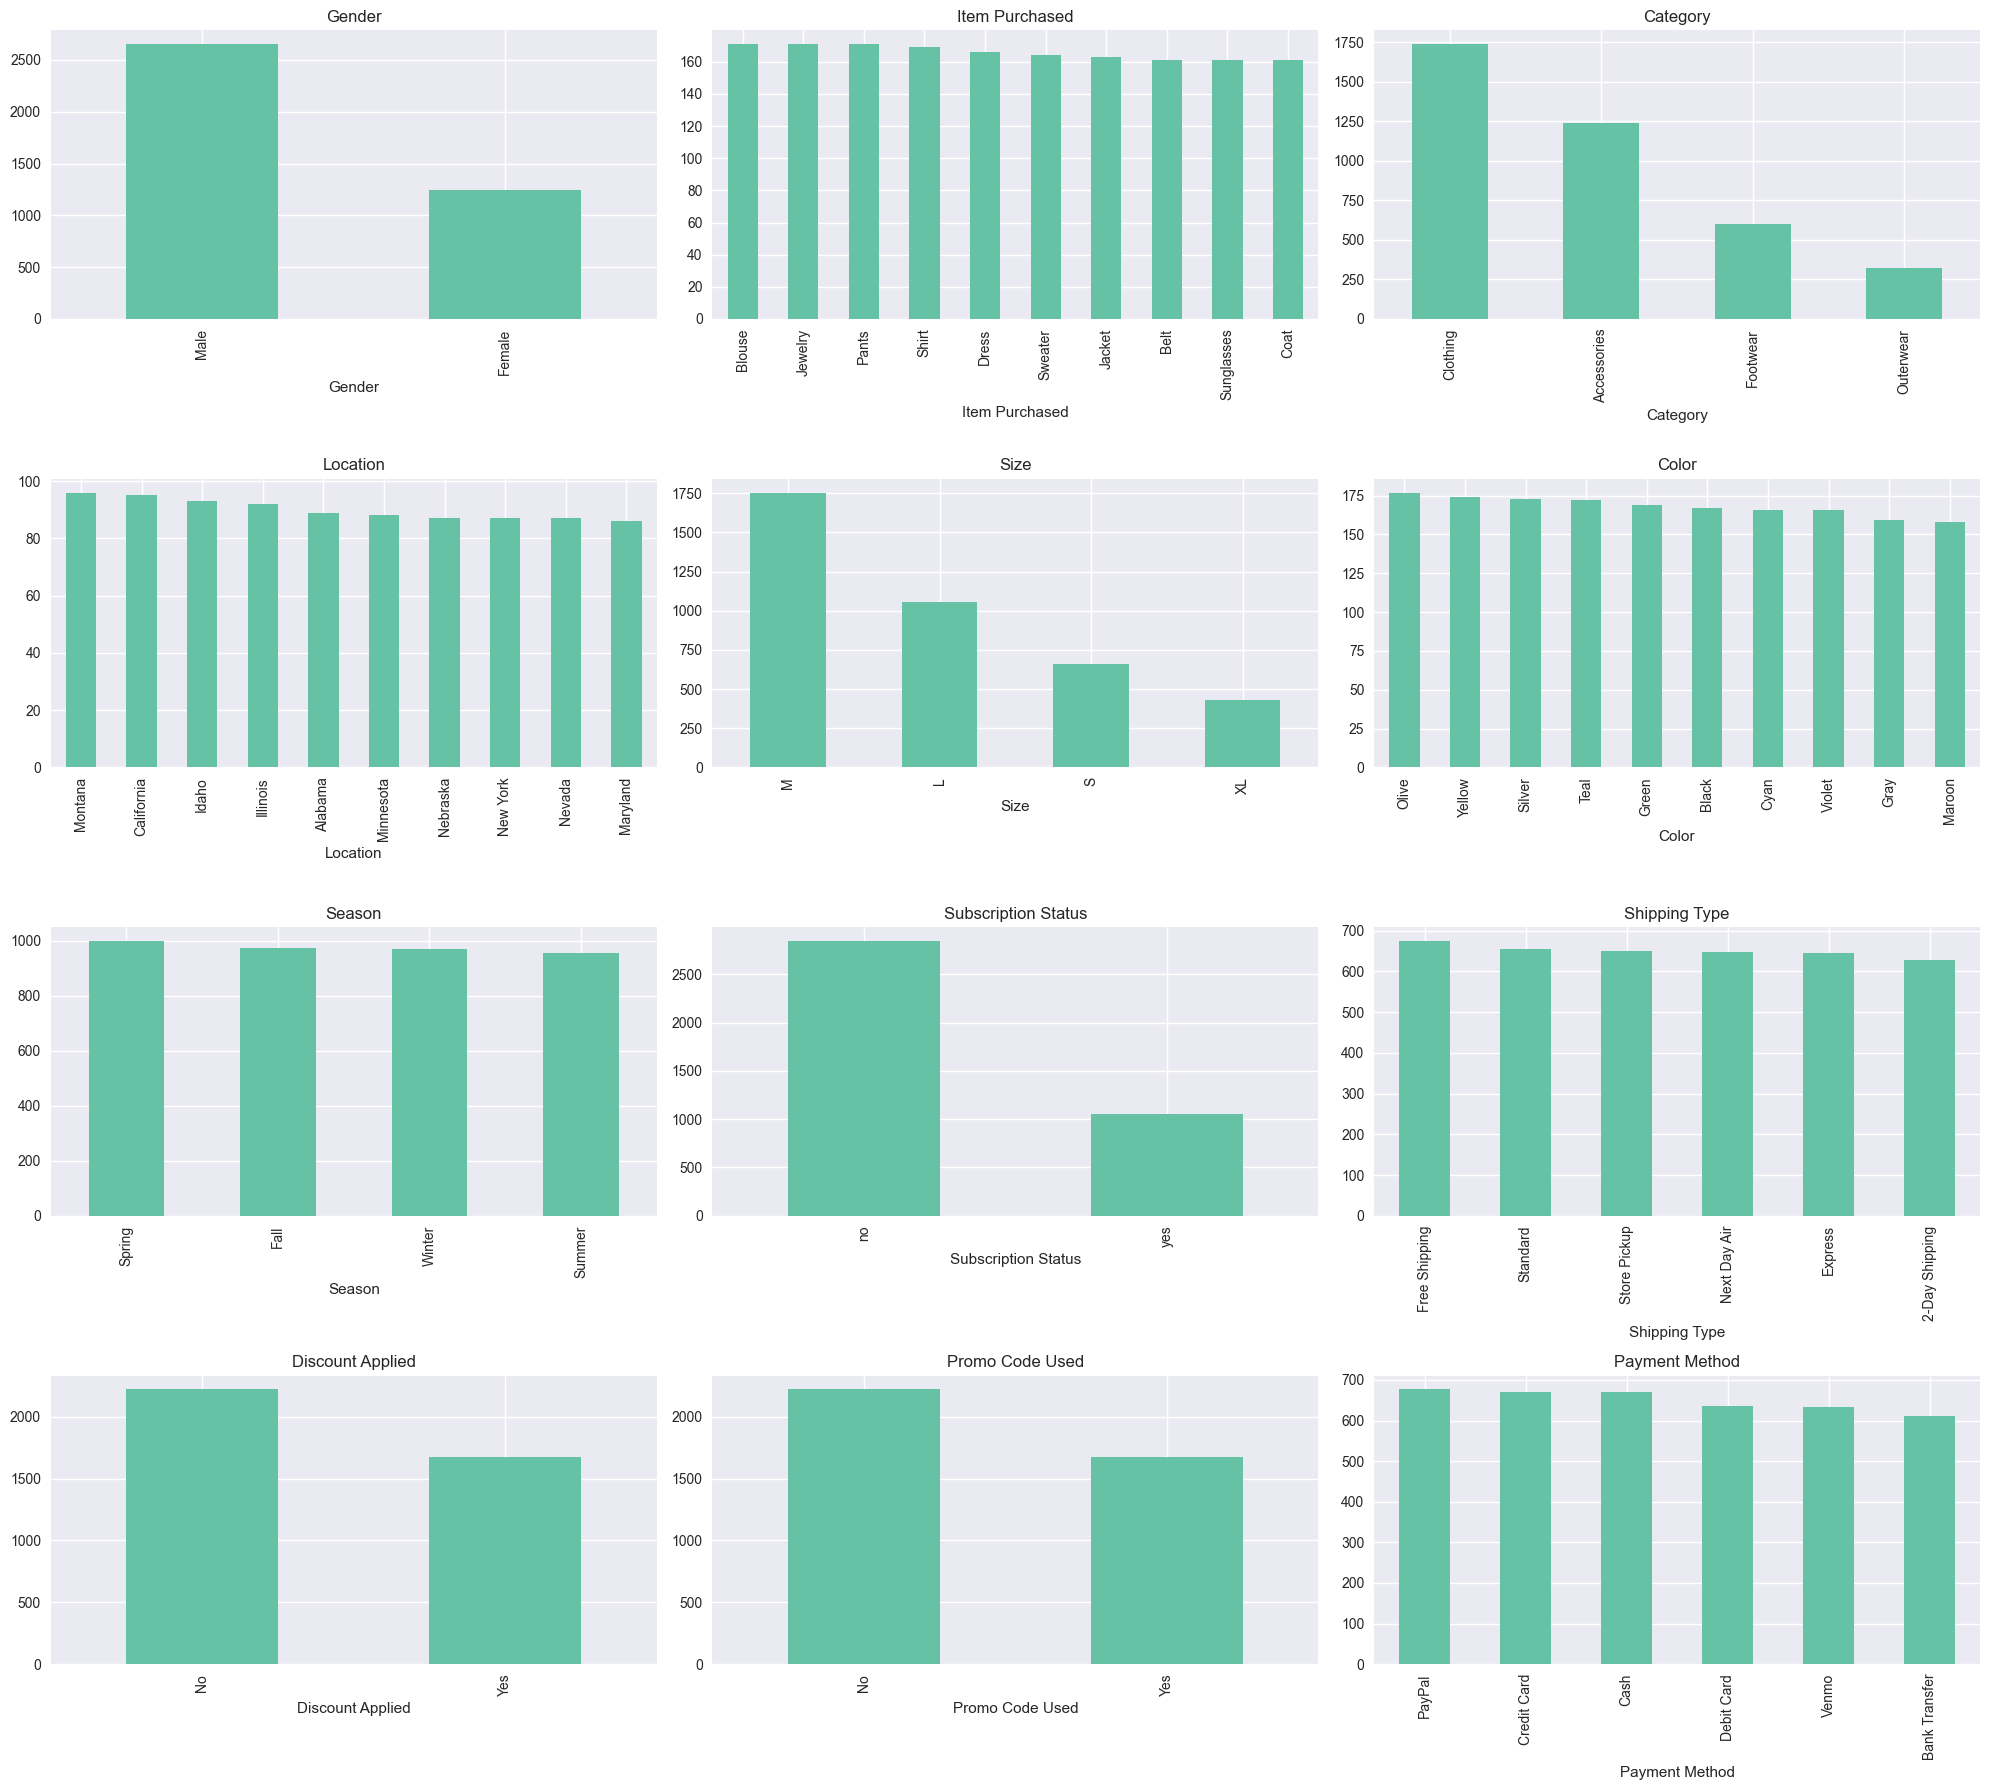

In [76]:
categorical_cols = ['Gender','Item Purchased','Category','Location','Size',
                    'Color','Season','Subscription Status','Shipping Type',
                    'Discount Applied','Promo Code Used','Payment Method',
                    'Frequency of Purchases']

plt.figure(figsize=(20,18))
for i,col in enumerate(categorical_cols[:12]):
    plt.subplot(4,3,i+1)
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(col)
plt.tight_layout()
plt.show()

In [80]:
print(f"--- P-VALUES cho '{TARGET_COL}' ({KEY_TRUE} vs {KEY_FALSE}) ---")

for col in numeric_cols:
    # Tách nhóm
    a = df[df[TARGET_COL] == KEY_TRUE][col].dropna()
    b = df[df[TARGET_COL] == KEY_FALSE][col].dropna()
    
    if len(a) > 1 and len(b) > 1:
        p_val = ttest_ind(a, b, equal_var=False).pvalue
        print(f"{col:<30} p-value = {p_val:.4e}")

--- P-VALUES cho 'Subscription Status' (yes vs no) ---
Age                            p-value = 6.8318e-01
Purchase Amount (USD)          p-value = 6.6029e-01
Review Rating                  p-value = 6.9141e-01
Previous Purchases             p-value = 5.0920e-02


category

In [78]:
def chi_square_test(feature):
    table = pd.crosstab(df[TARGET_COL], df[feature])
    chi2, p, dof, expected = chi2_contingency(table)
    return chi2, p, dof

# chỉ vẽ các cột categorical có số unique không quá lớn để dễ nhìn
cat_candidates = []
for c in categorical_cols:
    nunq = df[c].nunique(dropna=True)
    if nunq <= 12:
        cat_candidates.append(c)
        
print("Categorical (unique<=12) to visualize:", cat_candidates)


Categorical (unique<=12) to visualize: ['Gender', 'Category', 'Size', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']



* Crosstab % (rows sum to 100%) for: Gender


Gender,Female,Male
Subscription Status,,
no,43.84,56.16
yes,0.00,100.00


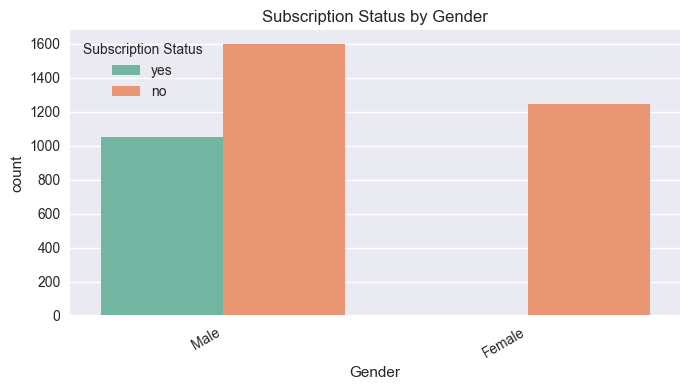


* Crosstab % (rows sum to 100%) for: Category


Category,Accessories,Clothing,Footwear,Outerwear
Subscription Status,,,,
no,31.82,44.96,15.03,8.18
yes,31.72,43.40,16.24,8.64


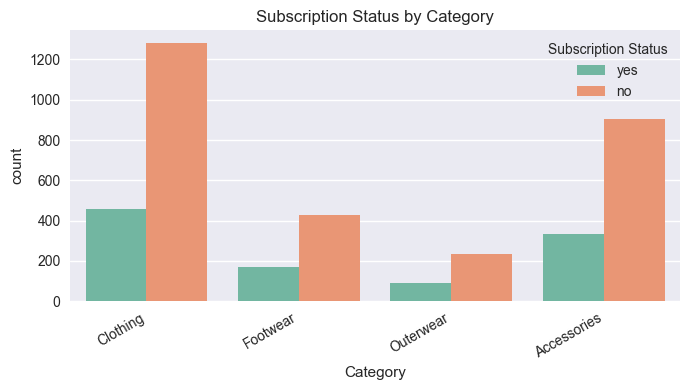


* Crosstab % (rows sum to 100%) for: Size


Size,L,M,S,XL
Subscription Status,,,,
no,26.62,45.06,17.18,11.13
yes,28.02,44.82,16.52,10.64


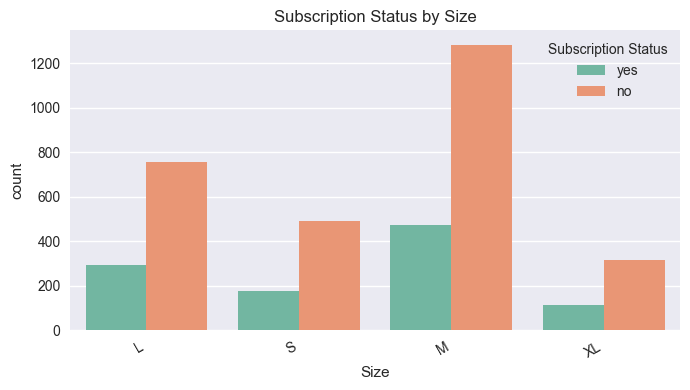


* Crosstab % (rows sum to 100%) for: Season


Season,Fall,Spring,Summer,Winter
Subscription Status,,,,
no,24.97,25.61,24.24,25.18
yes,25.07,25.64,25.17,24.12


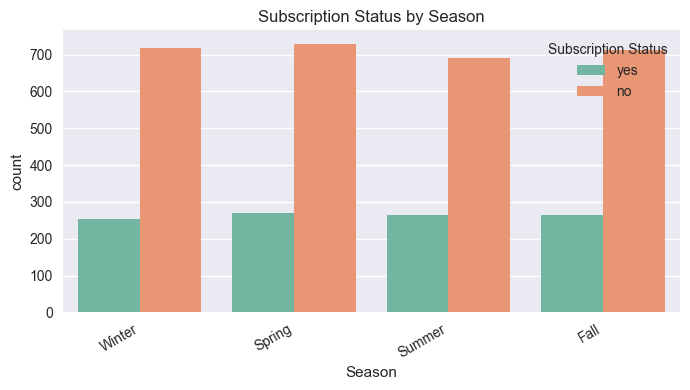


* Crosstab % (rows sum to 100%) for: Subscription Status


Subscription Status,no,yes
Subscription Status,,
no,100.0,0.0
yes,0.0,100.0


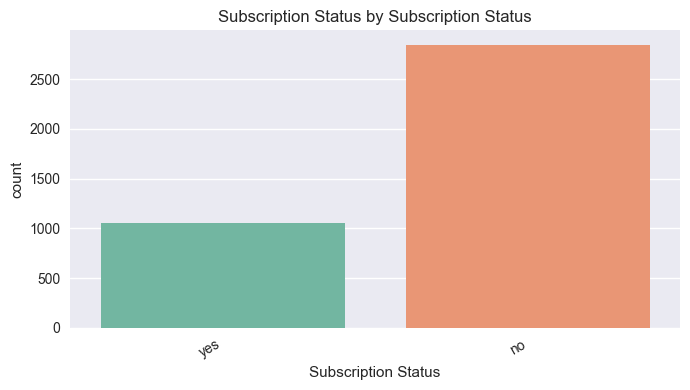


* Crosstab % (rows sum to 100%) for: Shipping Type


Shipping Type,2-Day Shipping,Express,Free Shipping,Next Day Air,Standard,Store Pickup
Subscription Status,,,,,,
no,16.65,16.02,17.49,16.86,16.82,16.16
yes,14.53,18.04,16.81,15.95,16.62,18.04


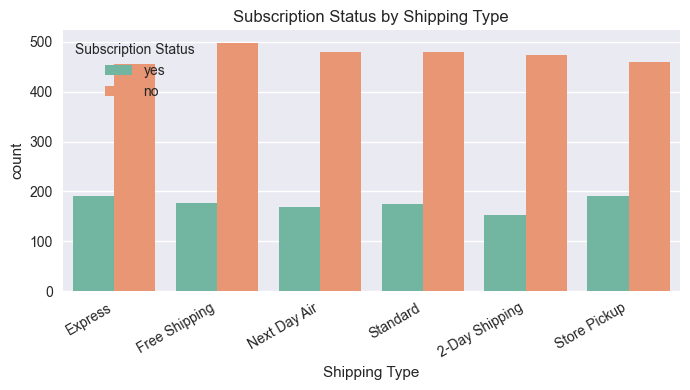


* Crosstab % (rows sum to 100%) for: Discount Applied


Discount Applied,No,Yes
Subscription Status,,
no,78.08,21.92
yes,0.00,100.00


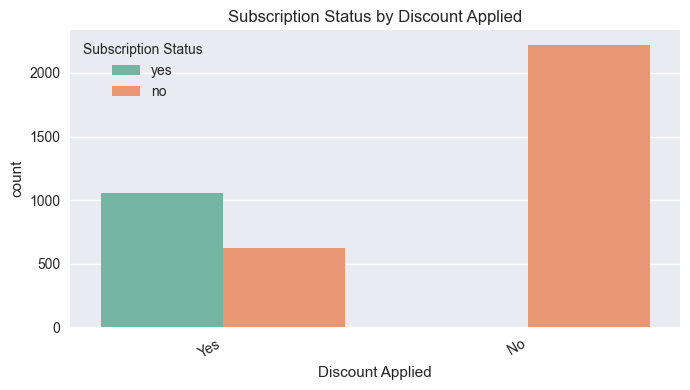


* Crosstab % (rows sum to 100%) for: Promo Code Used


Promo Code Used,No,Yes
Subscription Status,,
no,78.08,21.92
yes,0.00,100.00


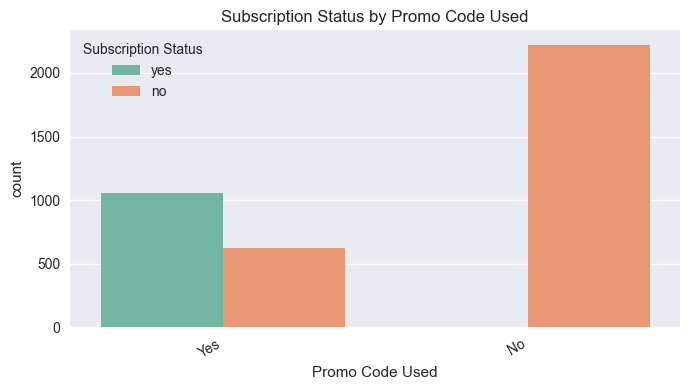


* Crosstab % (rows sum to 100%) for: Payment Method


Payment Method,Bank Transfer,Cash,Credit Card,Debit Card,PayPal,Venmo
Subscription Status,,,,,,
no,15.98,17.46,17.28,15.67,17.46,16.16
yes,14.91,16.43,17.00,18.04,17.09,16.52


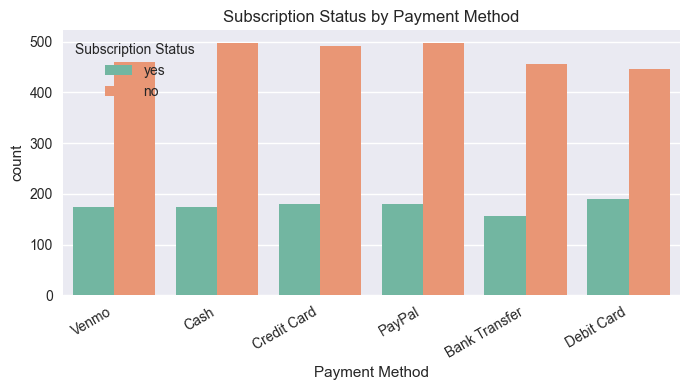


* Crosstab % (rows sum to 100%) for: Frequency of Purchases


Frequency of Purchases,Annually,Bi-Weekly,Every 3 Months,Fortnightly,Monthly,Quarterly,Weekly
Subscription Status,,,,,,,
no,14.47,14.3,15.10,13.66,14.19,14.86,13.42
yes,15.19,13.3,14.62,14.53,14.15,13.30,14.91


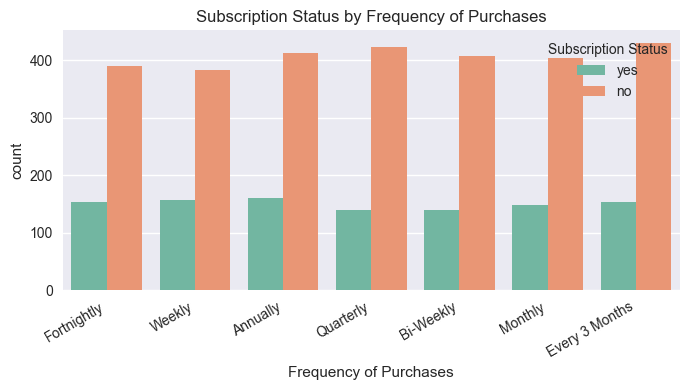


* Chi-square test summary:


,feature,chi2,p_value,dof,n_unique
4,Subscription Status,3894.928083,0.000000e+00,1,2
6,Discount Applied,1908.921365,0.000000e+00,1,2
7,Promo Code Used,1908.921365,0.000000e+00,1,2
0,Gender,676.794404,3.326863e-149,1,2
5,Shipping Type,6.300602,2.780580e-01,5,6
8,Payment Method,3.858743,5.699277e-01,5,6
9,Frequency of Purchases,3.894656,6.909298e-01,6,7
1,Category,1.344405,7.186167e-01,3,4
2,Size,0.926058,8.191353e-01,3,4
3,Season,0.623662,8.909948e-01,3,4


In [79]:
chi_rows = []
for col in cat_candidates:
    ct = pd.crosstab(df[TARGET_COL], df[col], normalize="index") * 100
    print(f"\n* Crosstab % (rows sum to 100%) for: {col}")
    display(ct.round(2))
    # countplot
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col, hue=TARGET_COL)
    plt.title(f"{TARGET_COL} by {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


    try:
        chi2, p, dof = chi_square_test(col)
        chi_rows.append([col, chi2, p, dof, df[col].nunique()])
    except Exception as e:
        chi_rows.append([col, np.nan, np.nan, np.nan, df[col].nunique()])

chi_df = pd.DataFrame(chi_rows, columns=["feature", "chi2", "p_value", "dof", "n_unique"]).sort_values("p_value")
print("\n* Chi-square test summary:")
display(chi_df)




thông qua bảng chéo (crosstab) và kiểm định Chi-square (kết quả P-value sẽ cực nhỏ, báo hiệu mối quan hệ bất thường).